# Code for Search Method (Change Point Detection)

In [ ]:
!pip3 install git+https://github.com/NetManAIOps/sktime.git

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from sktime.detection.mle_binseg import MLEBinSeg
from sktime.detection.optimal_partitioning import OptimalPartitioning

/var/folders/09/vy9lbtvd6532vkq3yfrht5w40000gn/T/ipykernel_56794/3729474950.py:15: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab20', num_segments)


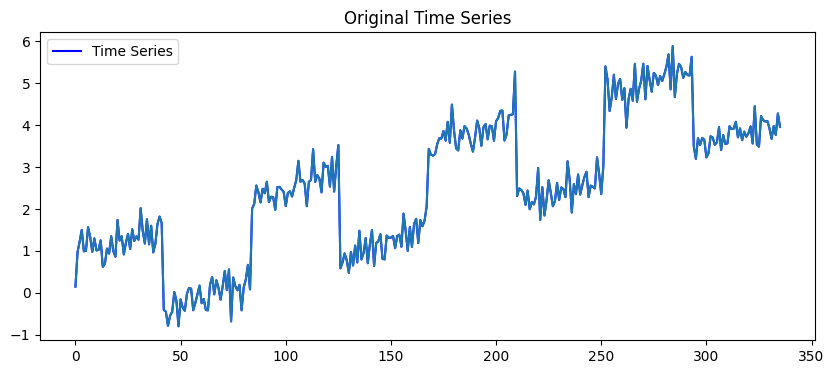

In [2]:
def generate_time_series(n=336, noise_level=0.3):
    """ Generate a square wave time series with noise and trends """
    np.random.seed(42)
    base_signal = np.sign(np.sin(np.linspace(0, 8 * np.pi, n)))
    trend = np.linspace(0, 5, n) 
    noise = noise_level * np.random.randn(n)
    return base_signal + trend + noise

def plot_segments(y, changepoints, title, use_alternating_colors=True):
    """ Plot time series data and segmentation results, with different colors for each segment """
    plt.figure(figsize=(10, 4))
    plt.plot(y, label="Time Series", color="blue")
    
    num_segments = len(changepoints) + 1
    colors = plt.cm.get_cmap('tab20', num_segments)
    
    start = 0
    for i, cp in enumerate(sorted(changepoints) + [len(y)]):
        plt.plot(range(start, cp), y[start:cp], color=colors(i))
        start = cp
    
    for cp in changepoints:
        plt.axvline(x=cp, color='red', linestyle='--', linewidth=1.5)
    
    plt.title(title)
    plt.legend()
    plt.show()

y = generate_time_series()
beta = 40

plot_segments(y, [], "Original Time Series")

BinSeg change points: [42, 84, 126, 168, 210, 252, 294]


/var/folders/09/vy9lbtvd6532vkq3yfrht5w40000gn/T/ipykernel_56794/3729474950.py:15: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab20', num_segments)


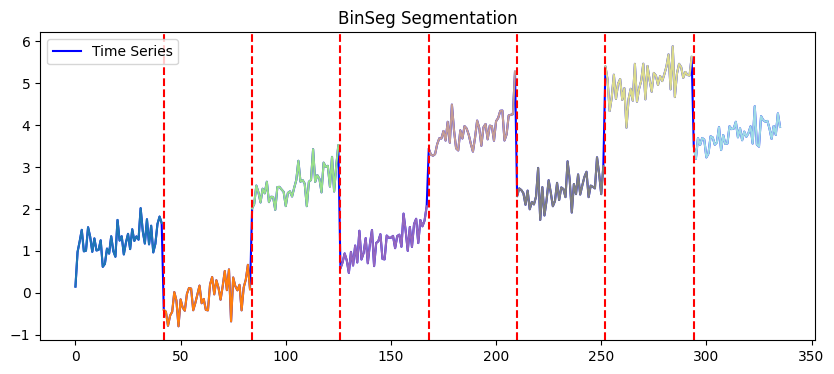

In [3]:
# BinSeg segmentation using sktime
binseg = MLEBinSeg(beta=beta)
binseg_result = binseg.fit_predict(pd.Series(y))
binseg_changepoints = binseg_result["ilocs"].tolist()
print("BinSeg change points:", binseg_changepoints)

plot_segments(y, binseg_changepoints, "BinSeg Segmentation")

OPT change points: [42, 84, 126, 168, 210, 252, 294]


/var/folders/09/vy9lbtvd6532vkq3yfrht5w40000gn/T/ipykernel_56794/3729474950.py:15: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab20', num_segments)


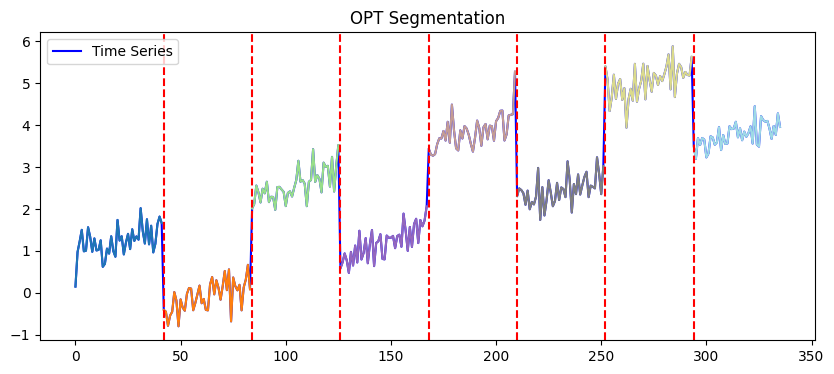

In [4]:
# OPT segmentation using sktime
opt = OptimalPartitioning(beta=beta)
opt_result = opt.fit_predict(pd.Series(y))
opt_changepoints = opt_result["ilocs"].tolist()
print("OPT change points:", opt_changepoints)

plot_segments(y, opt_changepoints, "OPT Segmentation")